# Lab 01 — Working with Increasingly Large Datasets

In this notebook, we will investigate how dataset size affects data processing in Python using pandas, csv, parquet and chunck processing.

We will:

- Create an artificial healthcare dataset.
- Increase the number of observations progressively.
- Measure file size, memory usage, and execution time.
- Compare CSV and Parquet.
- Explore the limitations of loading complete datasets into pandas.
- Process large files in chunks.
- Compare the results and performance of different approaches.

> **Important:** The goal is not to find a universal maximum number of rows for pandas. The practical limit depends on the computer, available memory, data types, and operation being performed. The objective is to understand how that affects memory usage, execution time and so on.


## The central question

Imagine that a healthcare organization gives us a dataset containing information about millions of encounters.

We want to answer questions such as:

- What is the average treatment cost?
- Which medical conditions are most common?
- How many encounters belong to each hospital?
- How can we process the data if it becomes too large to load comfortably into memory?

The central question is:

> **How does the way we store and process data affect the amount of data we can work with?**

We will investigate this question experimentally rather than relying only on theoretical explanations.


## 1. Import the required libraries

For this notebook we will use the following libraries:

- `pandas` for tabular data processing.
- `numpy` for efficient numerical data generation.
- `matplotlib` for visualizing measurements.
- `time` for execution-time measurements.
- `os` and `pathlib` for file-size and path operations.
- `gc` for explicitly releasing objects during the experiment.
- `platform` for recording basic information about the execution environment.


In [1]:
import gc
import os
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

The results of this experiment will depend on the computer you have and the software environment. Run the following cell to record some basic information about the environment you are using.


In [2]:
print(f"Python version: {platform.python_version()}")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Operating system: {platform.system()} {platform.release()}")


Python version: 3.11.7
pandas version: 3.0.5
NumPy version: 2.4.6
Operating system: Windows 10


In this notebook, we will generate artificial data to explore how data processing performance changes as datasets become increasingly large.

To keep the generated files organised, we will create a folder named `large_data_lab` relative to the location of this notebook. All datasets and related files created throughout the notebook will be stored in this folder.

In [3]:
DATA_DIR = Path("large_data_lab")
DATA_DIR.mkdir(exist_ok=True)

print(f"Working directory: {DATA_DIR.resolve()}")

Working directory: C:\Users\danie\Downloads\NOVA IMS\Lecturing\2026 - 2027\Big Data Analysis\BigDataAnalysis2627\weeks\week01\large_data_lab


## 2. Data description of the generated dataset

We will create a dataset in which each row represents a healthcare encounter. The dataset will contain the following variables:

| Variable | Description |
|---|---|
| `encounter_id` | Unique encounter identifier |
| `patient_id` | Patient identifier |
| `age` | Patient age |
| `medical_condition` | Main medical condition |
| `admission_date` | Date of admission |
| `length_of_stay` | Number of days in hospital |
| `treatment_cost` | Cost associated with treatment |
| `hospital_id` | Hospital identifier |
| `discharge_status` | Discharge outcome |

The cell below sets up the random number generator with a fixed seed to ensure reproducible results. It also defines the possible medical conditions and discharge statuses that will be used to generate artificial healthcare records later in the notebook.

In [4]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

CONDITIONS = np.array([
    "Diabetes",
    "Asthma",
    "Arthritis",
    "Cancer",
    "Infection",
    "Cardiovascular disease",
    "Fracture",
    "Neurological disorder"
])

DISCHARGE_STATUSES = np.array([
    "Home",
    "Transfer",
    "Rehabilitation",
    "Deceased"
])

The function below allows us to generate datasets with different numbers of rows.

We deliberately include different data types:

- Integers
- Floating-point numbers
- Strings
- Dates

This makes the experiment more realistic because different data types have different memory requirements.

In [5]:
def generate_healthcare_dataset(n_rows, seed=42):
    """Generate a synthetic healthcare dataset with n_rows observations."""
    local_rng = np.random.default_rng(seed)

    start_date = np.datetime64("2020-01-01")
    admission_offsets = local_rng.integers(0, 365 * 5, size=n_rows)

    return pd.DataFrame({
        "encounter_id": np.arange(1, n_rows + 1, dtype=np.int64),
        "patient_id": local_rng.integers(1, 500_001, size=n_rows, dtype=np.int64),
        "age": local_rng.integers(18, 91, size=n_rows, dtype=np.int16),
        "medical_condition": local_rng.choice(CONDITIONS, size=n_rows),
        "admission_date": start_date + admission_offsets.astype("timedelta64[D]"),
        "length_of_stay": local_rng.integers(1, 31, size=n_rows, dtype=np.int16),
        "treatment_cost": np.round(
            local_rng.uniform(100, 25_000, size=n_rows), 2
        ),
        "hospital_id": local_rng.integers(1, 101, size=n_rows, dtype=np.int16),
        "discharge_status": local_rng.choice(DISCHARGE_STATUSES, size=n_rows)
    })

## 3. Generate the first dataset

We begin with 1,000 observations. At this size, the dataset should be easy to inspect and process, allowing us to verify that the data generation process works as expected before scaling up.

Starting with a relatively small dataset also gives us a useful baseline for measuring processing time and memory usage. As we increase the number of observations, we will be able to compare how these resources change and explore the practical limits of working with large datasets in pandas.

In [6]:
df = generate_healthcare_dataset(1_000)

df.head()


,encounter_id,patient_id,age,medical_condition,admission_date,length_of_stay,treatment_cost,hospital_id,discharge_status
0,1,404151,29,Cardiovascular disease,2020-06-11,10,21084.03,59,Home
1,2,368353,82,Diabetes,2023-11-13,2,11215.10,62,Deceased
2,3,279159,44,Fracture,2023-04-09,25,23829.08,84,Rehabilitation
3,4,443202,22,Diabetes,2022-03-11,20,16304.79,83,Rehabilitation
4,5,64134,87,Diabetes,2022-03-01,21,2985.88,81,Transfer


In [7]:
df.shape


(1000, 9)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   encounter_id       1000 non-null   int64        
 1   patient_id         1000 non-null   int64        
 2   age                1000 non-null   int16        
 3   medical_condition  1000 non-null   str          
 4   admission_date     1000 non-null   datetime64[s]
 5   length_of_stay     1000 non-null   int16        
 6   treatment_cost     1000 non-null   float64      
 7   hospital_id        1000 non-null   int16        
 8   discharge_status   1000 non-null   str          
dtypes: datetime64[s](1), float64(1), int16(3), int64(2), str(2)
memory usage: 71.8 KB


## 4. Measuring DataFrame memory usage

A DataFrame occupies memory while it is being stored and processed. Understanding how much memory it uses is important when working with increasingly large datasets.

The `.memory_usage()` method allows us to inspect the memory consumption of each column in a DataFrame. By default, it returns the memory used by each column, including the index.

In the following cell, we will use this method to examine the memory footprint of our artificial healthcare dataset and establish a baseline before increasing its size.


In [9]:
df.memory_usage()


Index                  132
encounter_id          8000
patient_id            8000
age                   2000
medical_condition    18916
admission_date        8000
length_of_stay        2000
treatment_cost        8000
hospital_id           2000
discharge_status     16500
dtype: int64

The default result does not always provide a complete estimate for string/object data.

For a more informative estimate, we can use `deep=True`.


In [10]:
memory_bytes = df.memory_usage(deep=True).sum()
memory_mb = memory_bytes / 1024**2

print(f"Estimated DataFrame memory usage: {memory_mb:.2f} MB")


Estimated DataFrame memory usage: 0.07 MB


DataFrame memory usage is not necessarily equal to the size of the CSV file on disk because they represent the data in different ways.

- **Text representation:** CSV stores values as text, including numbers and dates. When loaded into pandas, these values are converted into more memory-efficient binary representations according to their data types.
- **Data types:** Pandas stores each column using a specific data type, such as integers, floating-point numbers, or strings. The memory required depends on these types and how the data is represented internally.
- **Compression:** A CSV file is generally not compressed, while other formats, such as Parquet, can use compression to significantly reduce the amount of storage required on disk.
- **Temporary objects:** During data processing, pandas may create temporary objects or intermediate results. These can temporarily increase memory usage beyond the memory occupied by the original DataFrame.

Therefore, **file size on disk and DataFrame memory usage measure two different things**: one measures how much storage is required to save the data, while the other measures how much memory is required to represent and process the data in pandas.

## 5. Measure execution time

We will use Python's `time.perf_counter()` to measure the elapsed time of different operations.

`time.perf_counter()` provides a high-resolution timer that is well suited for benchmarking and performance measurements. By recording the time immediately before and after an operation, we can calculate how long that operation took to complete.

This will allow us to compare the performance of different approaches, such as reading CSV and Parquet files, or processing data in chunks—under the same computing environment.


In [11]:
start = time.perf_counter()

mean_cost = df["treatment_cost"].mean()

elapsed = time.perf_counter() - start

print(f"Average treatment cost: {mean_cost:.2f}")
print(f"Execution time: {elapsed:.6f} seconds")

Average treatment cost: 12372.55
Execution time: 0.000886 seconds


In the following cells we will create some helper functions to compare datasets consistently. The functions will be used for:

- Measuring DataFrame memory.
- Measuring file size.
- Measuring execution time.


In [12]:
def dataframe_memory_mb(dataframe):
    """Return the estimated memory usage of a DataFrame in MB."""
    return dataframe.memory_usage(deep=True).sum() / 1024**2


def file_size_mb(path):
    """Return the size of a file in MB."""
    return Path(path).stat().st_size / 1024**2


def timed_call(function, *args, **kwargs):
    """Run a function and return its result and elapsed time in seconds."""
    start = time.perf_counter()
    result = function(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed

We will investigate how performance and memory usage change as the dataset grows. The experiment will use the following dataset sizes:

- **1,000 rows**
- **10,000 rows**
- **100,000 rows**
- **1,000,000 rows**
- **5,000,000 rows**

The largest dataset is optional, as generating and processing several million observations may require substantial time and memory. If generation becomes too slow or memory usage becomes excessive, stop the experiment and use the largest dataset that was successfully completed.

> To avoid unnecessarily consuming memory, **we will generate and process one dataset at a time** rather than keeping all dataset sizes in memory simultaneously. This also allows us to measure the performance of each size independently and consistently.

In [13]:
DATASET_SIZES = [1_000, 10_000, 100_000, 1_000_000, 5_000_000]

measurement_rows = []


## 6. Measure the in-memory DataFrame at each size

For each size, we will record:

- Number of rows.
- Number of columns.
- DataFrame memory usage.
- Time required to generate the dataset.

The results will be stored in a list of dictionaries.


In [14]:
for n_rows in DATASET_SIZES:
    print(f"Generating {n_rows:,} rows...")

    start = time.perf_counter()
    current_df = generate_healthcare_dataset(n_rows, seed=RANDOM_SEED)
    generation_time = time.perf_counter() - start

    measurement_rows.append({
        "rows": n_rows,
        "columns": current_df.shape[1],
        "generation_time_seconds": generation_time,
        "dataframe_memory_mb": dataframe_memory_mb(current_df)
    })

    print(
        f"Memory: {dataframe_memory_mb(current_df):.2f} MB | "
        f"Generation time: {generation_time:.3f} seconds"
    )

    del current_df
    gc.collect()

Generating 1,000 rows...
Memory: 0.07 MB | Generation time: 0.005 seconds
Generating 10,000 rows...
Memory: 0.70 MB | Generation time: 0.015 seconds
Generating 100,000 rows...
Memory: 7.02 MB | Generation time: 0.112 seconds
Generating 1,000,000 rows...
Memory: 70.21 MB | Generation time: 1.171 seconds
Generating 5,000,000 rows...
Memory: 351.05 MB | Generation time: 6.557 seconds


In [15]:
size_results = pd.DataFrame(measurement_rows)
size_results

,rows,columns,generation_time_seconds,dataframe_memory_mb
0,1000,9,0.004547,0.070141
1,10000,9,0.015258,0.703614
2,100000,9,0.112386,7.021564
3,1000000,9,1.170965,70.214406
4,5000000,9,6.557407,351.053861


If you remember data visualisation classes, a line chart is perfect to visualise how memory usage changes as the number of rows increases.

By plotting the dataset size against its corresponding memory usage, we can identify the overall trend and observe whether memory consumption grows proportionally as the dataset becomes larger. This helps us understand how the memory requirements of a pandas DataFrame scale with increasing dataset size.

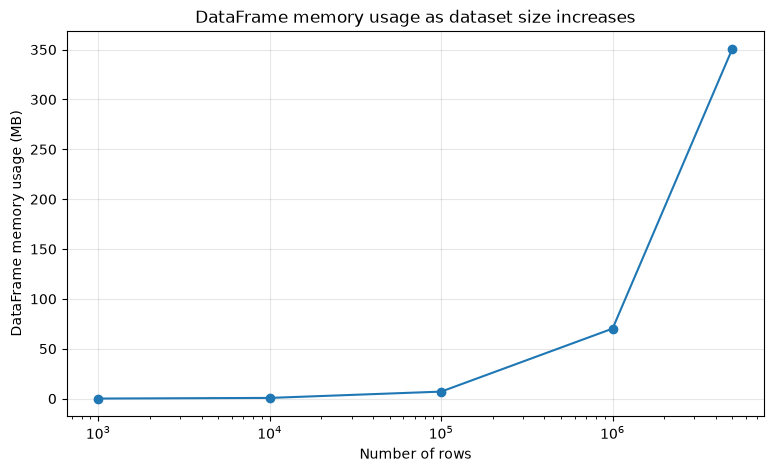

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    size_results["rows"],
    size_results["dataframe_memory_mb"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Number of rows")
plt.ylabel("DataFrame memory usage (MB)")
plt.title("DataFrame memory usage as dataset size increases")
plt.grid(True, alpha=0.3)
plt.show()

The graph shows how DataFrame memory usage changes as the number of observations increases. For the smaller datasets, memory consumption remains relatively low. However, as the dataset reaches one million and five million rows, memory usage increases substantially, reaching approximately 160 MB and 820 MB, respectively.

This illustrates an important characteristic of pandas: DataFrames are stored in memory, meaning that larger datasets require increasingly more RAM to be loaded and processed. In this example, memory usage grows approximately proportionally with the number of rows because the structure and data types of the dataset remain consistent.

When combined with our execution-time measurements, these results demonstrate the practical limits of processing increasingly large datasets with pandas. As datasets grow, both memory requirements and processing time can become significant, making pandas quite inefficient for daling with this large files.


## 7. CSV vs Parquet

We will now make a comparison between two storage formats: CSV and Parquet.

- **CSV (Comma-Separated Values):** A simple, text-based format that stores data in rows and columns. It is human-readable and widely supported, but it typically requires more storage space and can be slower to read and write for large datasets.
- **Parquet:** A columnar, binary storage format designed for efficient data storage and analytical workloads. It typically provides better compression and faster read/write performance than CSV, particularly for large datasets.

For this example we will compare the dataset with 1,000,000 rows and sate it as both a csv and a parquet file.

In [17]:
N_ROWS_COMPARISON = 1_000_000

df_comparison = generate_healthcare_dataset(
    N_ROWS_COMPARISON,
    seed=RANDOM_SEED
)

csv_path = DATA_DIR / "healthcare_1m.csv"

_, csv_write_time = timed_call(
    df_comparison.to_csv,
    csv_path,
    index=False
)

print(f"CSV path: {csv_path}")
print(f"CSV file size: {file_size_mb(csv_path):.2f} MB")
print(f"CSV write time: {csv_write_time:.3f} seconds")

CSV path: large_data_lab\healthcare_1m.csv
CSV file size: 61.40 MB
CSV write time: 7.352 seconds


The following cell may require a Parquet engine such as `pyarrow` or `fastparquet`.

In case you don't have them installed run the following lines of code:

```python
! pip install pyarrow==25.0.1 fastparquet
```

> **Warning:** If any errors occur make sure your Pandas version is `3.0.5` and everything should work fine.

In [18]:
parquet_path = DATA_DIR / "healthcare_1m.parquet"

try:
    _, parquet_write_time = timed_call(
        df_comparison.to_parquet,
        parquet_path,
        index=False
    )

    parquet_available = True

    print(f"Parquet path: {parquet_path}")
    print(f"Parquet file size: {file_size_mb(parquet_path):.2f} MB")
    print(f"Parquet write time: {parquet_write_time:.3f} seconds")

except ImportError:
    parquet_available = False
    parquet_write_time = np.nan

    print(
        "Parquet support is not available. "
        "Install pyarrow or fastparquet to run this section."
    )

Parquet path: large_data_lab\healthcare_1m.parquet
Parquet file size: 18.85 MB
Parquet write time: 1.018 seconds


We will now compare the file sizes of the CSV and Parquet versions of the dataset.

File size is an important consideration when working with large datasets. A smaller file requires **less storage space** and reduces the amount of data that needs to be **transferred or read from disk**.

We will compare the sizes of the two files to evaluate how effectively each format stores the same dataset.

In [21]:
format_results = pd.DataFrame({
    "format": ["CSV", "Parquet"],
    "file_size_mb": [
        file_size_mb(csv_path),
        file_size_mb(parquet_path) if parquet_available else np.nan
    ]
})

format_results

,format,file_size_mb
0,CSV,61.395137
1,Parquet,18.849807


In [22]:
if parquet_available:
    compression_ratio = (
        format_results.loc[format_results["format"] == "CSV", "file_size_mb"].iloc[0]
        /
        format_results.loc[format_results["format"] == "Parquet", "file_size_mb"].iloc[0]
    )

    print(f"CSV size / Parquet size: {compression_ratio:.2f}")
else:
    print("Compression ratio cannot be calculated without Parquet support.")


CSV size / Parquet size: 3.26


The results show a substantial difference in file size between the two formats. The **CSV file** is approximately **3.26 times larger** than the **Parquet file**. In other words, Parquet stores the same 1,000,000 rows using considerably less disk space.

This difference is mainly due to Parquet's columnar storage and compression, which allow data to be stored more efficiently than in a plain-text CSV file. A smaller file can reduce storage requirements and also decrease the amount of data that needs to be transferred or read from disk.

> **Note:** A smaller Parquet file does not automatically mean that pandas can load an unlimited amount of data. The file is stored efficiently on disk, but a normal `pd.read_parquet()` operation still creates a DataFrame in memory.

## 8. Comparing read times

We will now read the same dataset from both CSV and Parquet formats.

This comparison is meaningful because both files contain the same observations and variables, allowing us to isolate the effect of the storage format on data loading performance.

We will compare the time required to read the dataset from each format.

In [23]:
csv_df, csv_read_time = timed_call(
    pd.read_csv,
    csv_path
)

print(f"CSV read time: {csv_read_time:.3f} seconds")
print(f"CSV DataFrame memory: {dataframe_memory_mb(csv_df):.2f} MB")

CSV read time: 2.564 seconds
CSV DataFrame memory: 96.92 MB


In [24]:
if parquet_available:
    parquet_df, parquet_read_time = timed_call(
        pd.read_parquet,
        parquet_path
    )

    print(f"Parquet read time: {parquet_read_time:.3f} seconds")
    print(f"Parquet DataFrame memory: {dataframe_memory_mb(parquet_df):.2f} MB")
else:
    parquet_df = None
    parquet_read_time = np.nan
    print("Parquet comparison skipped.")

Parquet read time: 0.314 seconds
Parquet DataFrame memory: 70.21 MB


Although the CSV and Parquet files contain exactly the same data, they can have very different file sizes because the two formats store data in different ways.

**CSV** stores data as plain text, including separators and other formatting information. Parquet uses a binary, column-oriented format and can apply compression and more efficient encoding to the data. As a result, Parquet can often represent the same dataset using much less disk space.

**Parquet** can also be faster to read for analytical workloads. Because it stores data by column, it can efficiently access only the columns needed for an analysis instead of reading the entire dataset. Its compression and binary representation can also reduce the amount of data that needs to be read from disk.

However, these advantages are not guaranteed in every situation. The actual results depend on factors such as the dataset characteristics, compression settings, computer hardware, and software versions. Therefore, the results obtained in this experiment should be interpreted in the context of the specific environment in which the experiment was performed.

## 9. Compare memory after reading

The following code compares the **memory required by the DataFrames** created from the CSV and Parquet files.

It is important to distinguish between file size and memory usage. The file size measures how much space the data occupies on disk, while memory usage measures how much space is required to store the resulting DataFrame in RAM.

Therefore, a smaller file on disk does not necessarily mean that the corresponding DataFrame will require less memory when loaded into pandas.

In [25]:
read_results = pd.DataFrame({
    "format": ["CSV", "Parquet"],
    "read_time_seconds": [
        csv_read_time,
        parquet_read_time
    ],
    "dataframe_memory_mb": [
        dataframe_memory_mb(csv_df),
        dataframe_memory_mb(parquet_df) if parquet_available else np.nan
    ]
})

read_results

,format,read_time_seconds,dataframe_memory_mb
0,CSV,2.564128,96.917287
1,Parquet,0.314381,70.214406


### Key conclusion

> **Parquet can make storage and reading more efficient, but loading a complete Parquet file into pandas still requires memory for the resulting DataFrame.**

This distinction is essential:

- **Storage format** affects how data is stored and read.
- **Processing strategy** affects how much data is held in memory at one time.


One of the advantages of a columnar format is that we can request only the columns required for an analysis.

For example, suppose we only need:

- `medical_condition`
- `treatment_cost`

We do not need to load all other columns if we are using parquet, since it stores data by column, so it can read only the columns needed for an analysis. CSV in the other hand requires the file to be scanned and parsed to identify the requested columns, even when the other columns are not loaded into the final DataFrame. This is one reason why Parquet can be faster for analytical workloads, especially with large datasets.

In [26]:
if parquet_available:
    selected_df, selected_read_time = timed_call(
        pd.read_parquet,
        parquet_path,
        columns=["medical_condition", "treatment_cost"]
    )

    print(f"Read time: {selected_read_time:.3f} seconds")
    print(f"Memory: {dataframe_memory_mb(selected_df):.2f} MB")
    display(selected_df.head())
else:
    selected_df = None
    print("This example requires Parquet support.")

Read time: 0.114 seconds
Memory: 25.87 MB


,medical_condition,treatment_cost
0,Fracture,22994.21
1,Neurological disorder,10566.04
2,Infection,18775.57
3,Cancer,611.45
4,Infection,2419.06


## 10. Demonstrating the normal pandas workflow

The normal workflow loads the entire file into memory before processing it.

For example, to calculate the average treatment cost:


In [27]:
full_df = pd.read_csv(csv_path)

full_mean_cost = full_df["treatment_cost"].mean()

print(f"Average treatment cost: {full_mean_cost:.2f}")
print(f"DataFrame memory: {dataframe_memory_mb(full_df):.2f} MB")

Average treatment cost: 12546.08
DataFrame memory: 96.92 MB


This approach is convenient and often appropriate for small and medium-sized datasets.

However, as the dataset grows, loading the complete file may become slow, consume a large amount of memory, or fail.


## 11. Chunk processing

Chunk processing allows us to read and process a file in smaller portions.

Instead of loading the entire file:

```python
df = pd.read_csv("healthcare.csv")
```

we use:

```python
pd.read_csv("healthcare.csv", chunksize=100_000)
```

This returns an iterable that produces DataFrames, one chunk at a time.

In [28]:
chunk_size = 100_000

chunks = pd.read_csv(csv_path, chunksize=chunk_size)

for chunk_number, chunk in enumerate(chunks, start=1):
    print(f"Chunk {chunk_number}: {chunk.shape}")
    if chunk_number == 3:
        break

Chunk 1: (100000, 9)
Chunk 2: (100000, 9)
Chunk 3: (100000, 9)


### The main idea

```text
Large file
    |
    +--> Chunk 1 --> Process --> Discard
    |
    +--> Chunk 2 --> Process --> Discard
    |
    +--> Chunk 3 --> Process --> Discard
    |
    +--> ...
```

Only the current chunk needs to be held in memory for the processing step.


We will calculate the average treatment cost in two ways:

1. By loading the entire dataset.
2. By processing the CSV file in chunks.

The results should be the same, apart from very small floating-point differences, because both files contain exactly the same underlying data. The storage format changes how the data is stored and read, but not the values themselves.

In [31]:
full_mean_cost = full_df["treatment_cost"].mean()

print(f"Mean using the complete DataFrame: {full_mean_cost:.10f}")

Mean using the complete DataFrame: 12546.0837113200


In [32]:
total_cost = 0.0
total_count = 0

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    total_cost += chunk["treatment_cost"].sum()
    total_count += chunk["treatment_cost"].count()

chunk_mean_cost = total_cost / total_count

print(f"Mean using chunks: {chunk_mean_cost:.10f}")
print(f"Difference: {abs(full_mean_cost - chunk_mean_cost):.12f}")


Mean using chunks: 12546.0837113200
Difference: 0.000000000000


### Why do we calculate a weighted mean?

A common mistake is to calculate the mean of each chunk and then calculate the mean of those means.

That is only correct when every chunk contains the same number of observations.

The safer approach is to combine:

- The total sum.
- The total number of valid observations.

Then:

$$
\text{Mean} = \frac{\text{Total Sum}}{\text{Total Count}}
$$

## 12. Measuring complete-file processing versus chunk processing

We will now compare two approaches for processing the same CSV dataset using:

- **Complete DataFrame:** The entire dataset is loaded into memory before calculating the mean treatment cost.
- **Chunk processing:** The dataset is read and processed in smaller chunks, so the entire dataset does not need to be held in memory at once.

We will measure the execution time of both approaches and compare their results.

In [33]:
def mean_cost_from_full_csv(path):
    data = pd.read_csv(path)
    return data["treatment_cost"].mean()


def mean_cost_from_chunks(path, chunksize=100_000):
    total_cost = 0.0
    total_count = 0

    for chunk in pd.read_csv(path, chunksize=chunksize):
        total_cost += chunk["treatment_cost"].sum()
        total_count += chunk["treatment_cost"].count()

    return total_cost / total_count

In [34]:
_, full_processing_time = timed_call(
    mean_cost_from_full_csv,
    csv_path
)

_, chunk_processing_time = timed_call(
    mean_cost_from_chunks,
    csv_path,
    100_000
)

processing_results = pd.DataFrame({
    "approach": ["Complete DataFrame", "Chunk processing"],
    "time_seconds": [
        full_processing_time,
        chunk_processing_time
    ]
})

processing_results


,approach,time_seconds
0,Complete DataFrame,2.467588
1,Chunk processing,2.609787


Chunk processing may be slower because it performs multiple read operations and combines partial results.

However, its main advantage is **memory control**, as the entire dataset does not need to be loaded into memory at once. **Memory control** is important because **RAM is limited**. When a dataset is too large to fit comfortably in memory, loading the entire dataset into a pandas DataFrame can cause excessive memory usage, slow down the computer, or even lead to an **out-of-memory error**. 

**Chunk processing** helps by keeping only a small portion of the dataset in memory at a time. This allows us to process datasets that may be much larger than the amount of RAM available.

> **Memory efficiency and execution speed are different concepts.**

We can also calculate categorical frequencies incrementally.

The following code counts the number of encounters associated with each medical condition using chunck processing.

In [35]:
condition_counts = {}

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    partial_counts = chunk["medical_condition"].value_counts()

    for condition, count in partial_counts.items():
        condition_counts[condition] = (
            condition_counts.get(condition, 0) + count
        )

condition_counts = pd.Series(condition_counts).sort_values(ascending=False)

condition_counts

Neurological disorder     125294
Asthma                    125205
Infection                 125125
Fracture                  125058
Arthritis                 125038
Diabetes                  124975
Cardiovascular disease    124663
Cancer                    124642
dtype: int64

The next example combines grouping with chunk processing to calculate the mean treatment cost for each medical condition.

For each chunk, we calculate the total treatment cost and number of observations for each condition. We then combine these partial results across all chunks.

Finally, we calculate the mean treatment cost for each condition using:

$$
\text{Mean Cost} = \frac{\text{Total Cost}}{\text{Count}}
$$

This approach allows us to perform the analysis without loading the entire dataset into memory at once.

In [36]:
grouped_sum = {}
grouped_count = {}

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    partial_sum = chunk.groupby("medical_condition")["treatment_cost"].sum()
    partial_count = chunk.groupby("medical_condition")["treatment_cost"].count()

    for condition, value in partial_sum.items():
        grouped_sum[condition] = grouped_sum.get(condition, 0) + value

    for condition, value in partial_count.items():
        grouped_count[condition] = grouped_count.get(condition, 0) + value

mean_cost_by_condition = (
    pd.DataFrame({
        "total_cost": pd.Series(grouped_sum),
        "count": pd.Series(grouped_count)
    })
    .assign(mean_cost=lambda data: data["total_cost"] / data["count"])
    .sort_values("mean_cost", ascending=False)
)

mean_cost_by_condition


,total_cost,count,mean_cost
Arthritis,1.572701e+09,125038,12577.780739
Diabetes,1.570690e+09,124975,12568.033487
Infection,1.572288e+09,125125,12565.738460
Fracture,1.570849e+09,125058,12560.962709
Asthma,1.570960e+09,125205,12547.099895
Cardiovascular disease,1.561870e+09,124663,12528.735913
Neurological disorder,1.567646e+09,125294,12511.739103
Cancer,1.559081e+09,124642,12508.472204


Chunk processing is not limited to calculating statistics.

We can also:

- Filter rows.
- Transform values.
- Clean data.
- Save the result to another file.

The following example keeps encounters with treatment costs above 20,000.

In [37]:
filtered_csv_path = DATA_DIR / "high_cost_encounters.csv"

if filtered_csv_path.exists():
    filtered_csv_path.unlink()

first_chunk = True
total_filtered_rows = 0

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    filtered = chunk[chunk["treatment_cost"] > 20_000]
    total_filtered_rows += len(filtered)

    filtered.to_csv(
        filtered_csv_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print(f"Filtered rows: {total_filtered_rows:,}")
print(f"Output file size: {file_size_mb(filtered_csv_path):.2f} MB")


Filtered rows: 201,134
Output file size: 12.43 MB


In [38]:
filtered_df = pd.read_csv(filtered_csv_path)

filtered_df.head()

,encounter_id,patient_id,age,medical_condition,admission_date,length_of_stay,treatment_cost,hospital_id,discharge_status
0,1,409260,76,Fracture,2020-06-11,6,22994.21,38,Transfer
1,11,369933,32,Infection,2022-08-18,7,23113.61,9,Home
2,14,193985,76,Asthma,2023-10-21,15,24557.02,4,Rehabilitation
3,17,46614,58,Neurological disorder,2022-07-25,4,22435.02,79,Deceased
4,18,382656,20,Fracture,2020-08-21,8,21522.94,77,Deceased


### Why do we use `mode="a"`?

- `mode="w"` creates a new file or overwrites an existing file.
- `mode="a"` appends to an existing file.
- We write the header only for the first chunk.

This prevents the column names from being repeated for every chunk.


## 13. Comparing different chunk sizes

The chunk size is a parameter that affects the processing strategy.

We will compare several chunk sizes for the same mean-calculation task.


In [39]:
chunk_sizes = [10_000, 50_000, 100_000, 250_000, 500_000]

chunk_measurements = []

for size in chunk_sizes:
    _, elapsed = timed_call(
        mean_cost_from_chunks,
        csv_path,
        size
    )

    chunk_measurements.append({
        "chunk_size": size,
        "time_seconds": elapsed
    })

chunk_results = pd.DataFrame(chunk_measurements)

chunk_results

,chunk_size,time_seconds
0,10000,3.756752
1,50000,2.681994
2,100000,2.687217
3,250000,2.413751
4,500000,2.426576


Let's visualise them using a line chart.

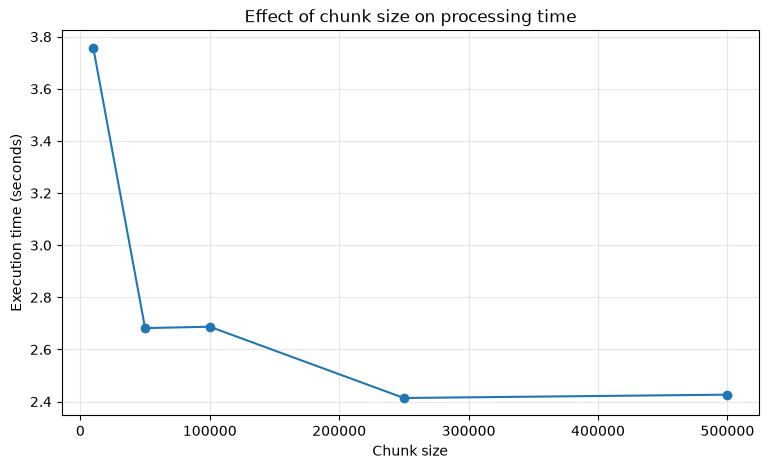

In [40]:
plt.figure(figsize=(9, 5))

plt.plot(
    chunk_results["chunk_size"],
    chunk_results["time_seconds"],
    marker="o"
)

plt.xlabel("Chunk size")
plt.ylabel("Execution time (seconds)")
plt.title("Effect of chunk size on processing time")
plt.grid(True, alpha=0.3)
plt.show()


There is no universally optimal chunk size.

- Very small chunks may increase overhead because the file is read many times.
- Very large chunks may increase memory usage.
- A practical chunk size depends on the dataset, available memory, and operation.

Chunk processing is a trade-off between memory usage and processing overhead.

## 14. Processing Parquet in batches

CSV has a direct `chunksize` argument in `pd.read_csv()`.

**Parquet is different:** it is a columnar format and is commonly processed using row groups or a library such as PyArrow.

The following example uses PyArrow to read Parquet in batches.

In [41]:
if parquet_available:
    try:
        import pyarrow.parquet as pq

        parquet_file = pq.ParquetFile(parquet_path)

        print(f"Number of row groups: {parquet_file.num_row_groups}")

        for batch_number, batch in enumerate(
            parquet_file.iter_batches(batch_size=100_000),
            start=1
        ):
            print(f"Batch {batch_number}: {batch.num_rows:,} rows")

            if batch_number == 3:
                break

    except ImportError:
        print(
            "PyArrow is not available. "
            "Install pyarrow to run this optional example."
        )
else:
    print("This example requires Parquet support.")


Number of row groups: 1
Batch 1: 100,000 rows
Batch 2: 100,000 rows
Batch 3: 100,000 rows


CSV chunk processing and Parquet batch processing follow the same general idea:

> Read a manageable portion of the data, process it, and continue.

However, the implementation depends on the storage format and the tools being used.

## Final comparison of approaches

We can summarize the approaches as follows:

| Approach | Storage format | Memory strategy | Typical use |
|---|---|---|---|
| Normal pandas | CSV | Load the complete file | Small and medium datasets |
| Normal pandas | Parquet | Load the complete file | Analytical workloads |
| Chunk processing | CSV | Load one chunk at a time | Large files |
| Batch processing | Parquet | Read selected columns or batches | Larger analytical workloads |

The best choice depends on:

- Dataset size.
- Available memory.
- Required operations.
- Storage format.
- Whether the analysis can be expressed using partial results.

**Summary of the presented concepts:**

1. Increasing the number of rows increases memory usage.
2. File size and DataFrame memory usage are different measurements.
3. CSV is simple and widely supported, but it is a text-based format.
4. Parquet is a columnar format that can reduce storage size and improve analytical reads.
5. Loading a complete Parquet file into pandas still requires memory.
6. Chunk processing allows us to process large files incrementally.
7. Chunk processing can reduce memory requirements, although it may introduce additional execution overhead.
8. The appropriate strategy depends on the dataset and the task in hands.

> **The central lesson is that scalable data processing requires us to think about storage, memory, and computation together.**